# Pneumonia Detection from Chest X-Ray Images using CNN and Transfer Learning


In [1]:
!pip install -q kaggle

In [2]:
## 1. Setting Up the Dataset
# upload kaggle.json here
from google.colab import files

files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nnm24am018","key":"08ade0acfe83f0b63229b519ae5c67e0"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:24<00:00, 99.0MB/s]



In [5]:
import zipfile

with zipfile.ZipFile("chest-xray-pneumonia.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
#2. Exploring the Dataset
import os

TRAIN_DIR = "dataset/chest_xray/train"
TEST_DIR = "dataset/chest_xray/test"

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']


In [7]:
# Number of Images in Each Class
for folder in ["NORMAL", "PNEUMONIA"]:
    train_count = len(os.listdir(os.path.join(TRAIN_DIR, folder)))
    test_count = len(os.listdir(os.path.join(TEST_DIR, folder)))

    print(f"{folder}:")
    print(f"  Training images: {train_count}")
    print(f"  Testing images:  {test_count}")

NORMAL:
  Training images: 1341
  Testing images:  234
PNEUMONIA:
  Training images: 3875
  Testing images:  390


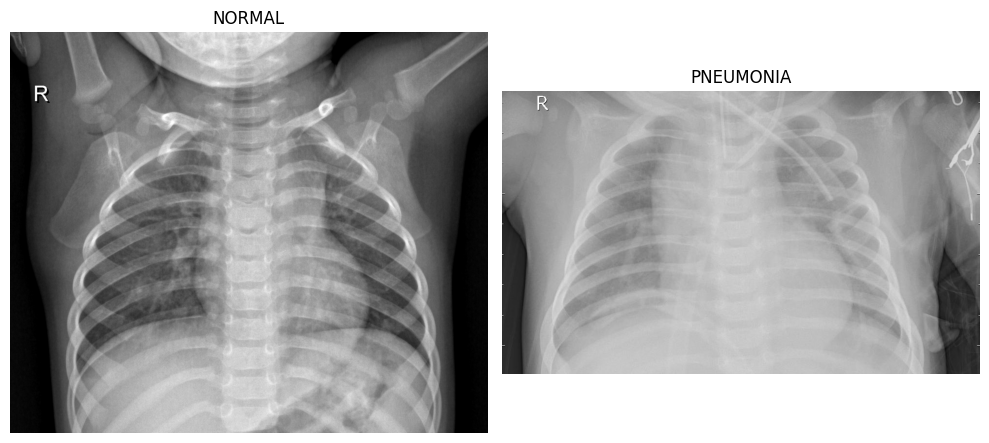

In [8]:
# 3. Visualizing Sample Chest X-Ray Images
import matplotlib.pyplot as plt
import random
from PIL import Image

classes = ["NORMAL", "PNEUMONIA"]

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

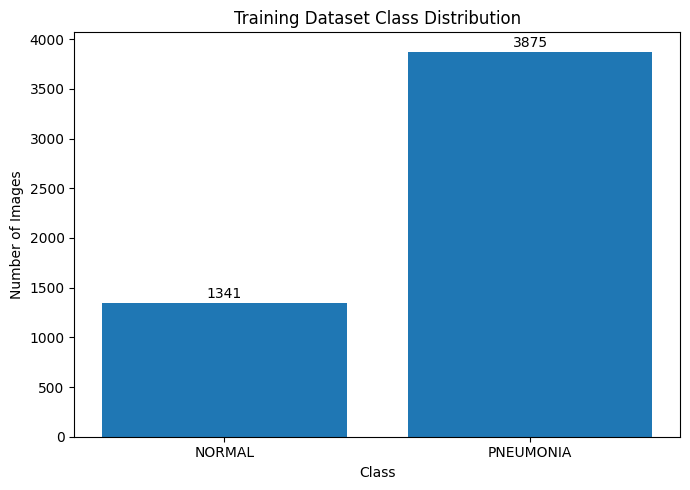

In [9]:
## 4. Class Distribution
import matplotlib.pyplot as plt

normal_count = len(os.listdir(os.path.join(TRAIN_DIR, "NORMAL")))
pneumonia_count = len(os.listdir(os.path.join(TRAIN_DIR, "PNEUMONIA")))

classes = ["NORMAL", "PNEUMONIA"]
counts = [normal_count, pneumonia_count]

plt.figure(figsize=(7, 5))
plt.bar(classes, counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha="center")

plt.tight_layout()
plt.show()

In [10]:
## 5. Image Preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation and test data
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
# 6. Transfer Learning using MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", "recall"]
)

In [13]:
# 7. Training the Model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 780ms/step - accuracy: 0.8970 - loss: 0.2266 - recall: 0.9400 - val_accuracy: 0.9166 - val_loss: 0.2016 - val_recall: 0.8929
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 690ms/step - accuracy: 0.9365 - loss: 0.1589 - recall: 0.9542 - val_accuracy: 0.9636 - val_loss: 0.1096 - val_recall: 0.9652
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 91s 693ms/step - accuracy: 0.9494 - loss: 0.1352 - recall: 0.9658 - val_accuracy: 0.9655 - val_loss: 0.1096 - val_recall: 0.9652
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 675ms/step - accuracy: 0.9504 - loss: 0.1235 - recall: 0.9635 - val_accuracy: 0.9386 - val_loss: 0.1410 - val_recall: 0.9213
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 689ms/step - accuracy: 0.9461 - loss: 0.1346 - recall: 0.9632 - val_accuracy: 0.9300 - val_loss: 0.1559 - val_recall: 0.9097
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 92s 704ms/step - accuracy: 0.9526 - loss: 0.1172 - recall: 0.9687 - val_accuracy: 0.9271 - val_loss: 0.1698 - val_

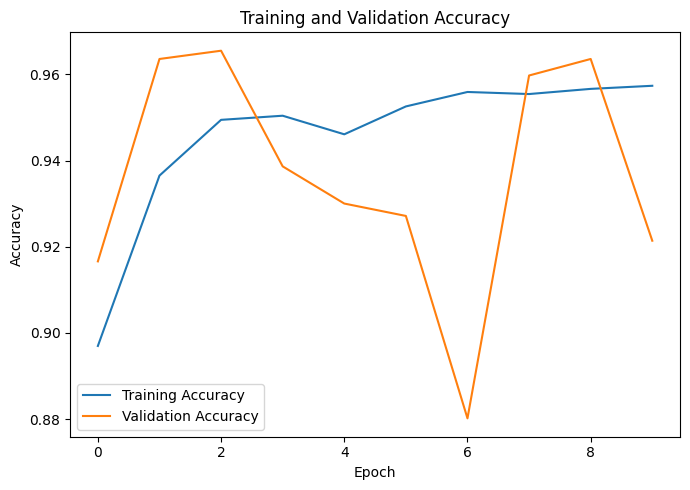

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

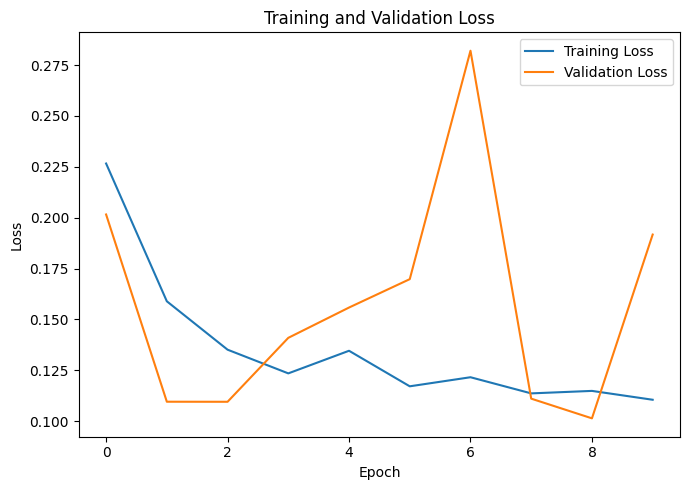

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_accuracy, test_recall = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Recall:", test_recall)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 426ms/step - accuracy: 0.8990 - loss: 0.2485 - recall: 0.9641
Test Loss: 0.24846221506595612
Test Accuracy: 0.8990384340286255
Test Recall: 0.964102566242218


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 398ms/step


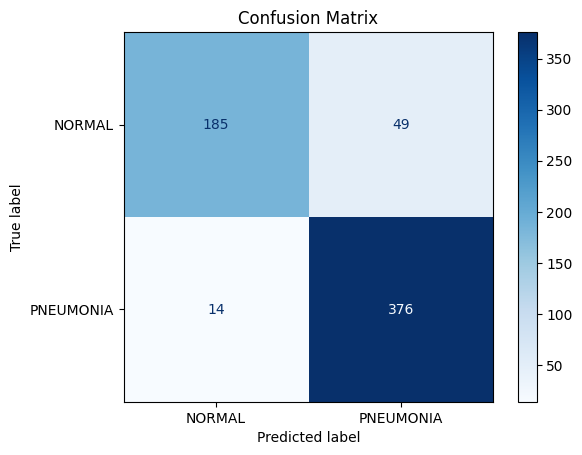

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.93      0.79      0.85       234
   PNEUMONIA       0.88      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).ravel()

true_classes = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


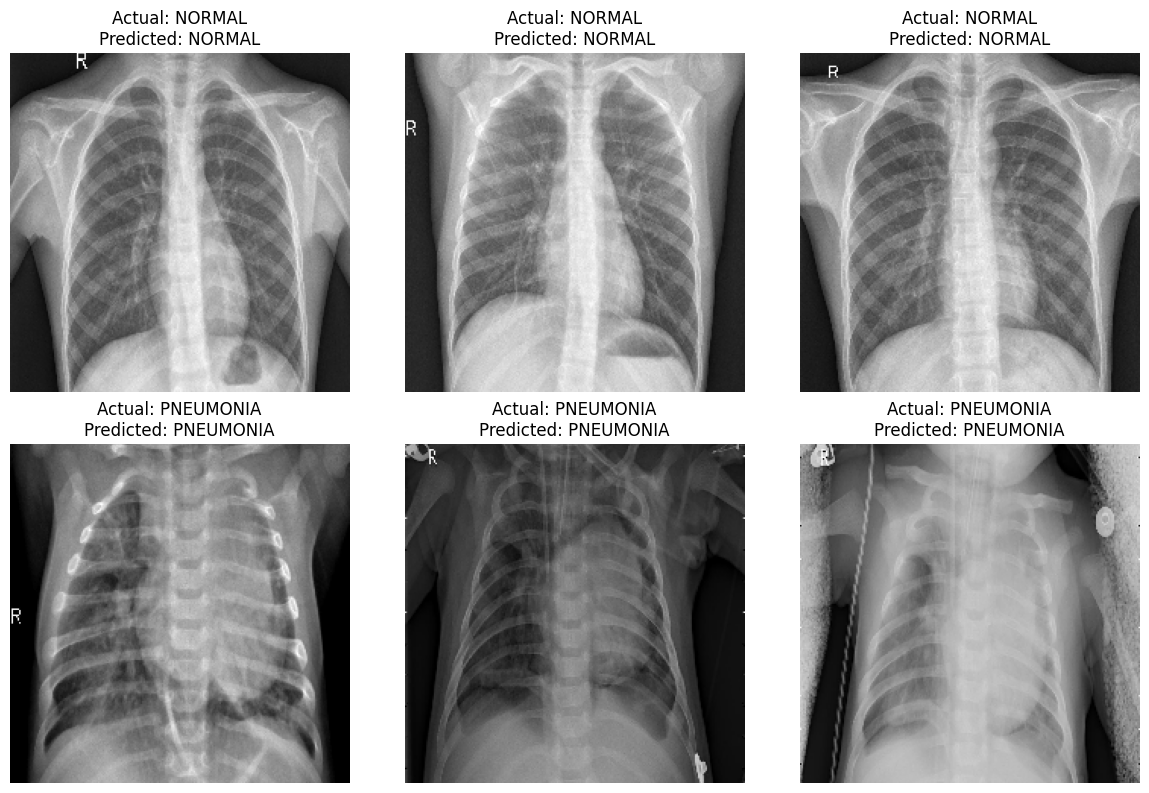

In [18]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["NORMAL", "PNEUMONIA"]
threshold = 0.6

images_to_show = []
labels_to_show = []
preds_to_show = []

# keep looping until we have at least 3 NORMAL and 3 PNEUMONIA
normal_count, pneumonia_count = 0, 0
while normal_count < 3 or pneumonia_count < 3:
    images, labels = next(test_generator)
    predictions = model.predict(images)
    predicted_classes = (predictions > threshold).astype(int).ravel()

    for i in range(len(images)):
        actual = int(labels[i])
        predicted = int(predicted_classes[i])
        if actual == predicted:  # only keep correct predictions
            if actual == 0 and normal_count < 3:
                images_to_show.append(images[i])
                labels_to_show.append(actual)
                preds_to_show.append(predicted)
                normal_count += 1
            elif actual == 1 and pneumonia_count < 3:
                images_to_show.append(images[i])
                labels_to_show.append(actual)
                preds_to_show.append(predicted)
                pneumonia_count += 1
        if normal_count >= 3 and pneumonia_count >= 3:
            break

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.squeeze(images_to_show[i]), cmap="gray")
    plt.title(f"Actual: {class_names[labels_to_show[i]]}\nPredicted: {class_names[preds_to_show[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
